<a href="https://colab.research.google.com/github/Swag-Pseudopy/LLMs-Flow-matching-and-more/blob/main/DFS_Game_of_24_ToT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎮 Tree-of-Thoughts (ToT) for Game of 24 — Groq API (Colab Notebook)

This Colab notebook implements the **Game of 24** using the **Tree-of-Thoughts (ToT)** framework (BFS search + LLM-based propose + value evaluation), inspired by the *Tree of Thoughts: Deliberate Problem Solving with Large Language Models* paper.

It is designed to be:
- **One-cell runnable**
- **Groq API based**
- **Verbose / traceable** (prints the full ToT search trace)
- **Strictly consistent** across steps: the `left:` numbers at each step are *exactly* the remaining numbers after applying the operation.

---

## ✅ What is Game of 24?

Given **4 numbers**, you must use:
- `+`, `-`, `*`, `/`
- each number **exactly once**
- parentheses allowed implicitly by stepwise reduction

to obtain **24**.

Example:

(10 - 4) * (13 - 9) = 24
---

## 🌳 What is Tree-of-Thoughts (ToT) here?

Instead of generating one long chain-of-thought, we do a **tree search**:

### Each node/state contains:
- Remaining numbers (e.g. `4 4 10`)
- A list of intermediate steps taken so far

### Each depth step:
1. **Propose** multiple candidate next moves (LLM)
2. **Validate** them strictly
3. **Evaluate** each candidate state (LLM → sure/maybe/impossible)
4. **Prune** low-value states
5. Keep only the top-`B` states (BFS)

---

## 🔍 Thought Decomposition (24-game specific)

We decompose reasoning into **3 steps** (depth `T = 3`):

- Step 1: combine 2 numbers → 3 numbers remain  
- Step 2: combine 2 numbers → 2 numbers remain  
- Step 3: combine 2 numbers → 1 number remains (goal = 24)

Example trace format:
```

13 - 9 = 4 (left: 4 4 10)
10 - 4 = 6 (left: 4 6)
4 * 6 = 24 (left: 24)

```

---

## 🧠 LLM Roles in ToT

### 1) Thought Generation: `PROPOSE`
The LLM proposes `K` next steps in the strict format:
```

a op b = c (left: ...)

```

### 2) Thought Evaluation: `VALUE`
The LLM judges a state as:
- `sure`      → likely solvable
- `maybe`     → uncertain
- `impossible`→ should be pruned

We sample the value judgment multiple times (`VALUE_SAMPLES`) and average scores.

---

## ✂️ Pruning and Why It Matters

### Problem observed without pruning:
- Repeated candidate states flood the search
- “Impossible” paths may continue till the end

### Fixes included in this notebook:
✅ **Hard pruning** using `V_THRESHOLD`  
States with average score ≤ threshold are removed.

✅ **Deduplication**  
States with identical remaining numbers are merged (we keep the best one).

---

## ⚙️ Configuration Parameters

You can tune these in the cell:

| Parameter | Meaning | Typical value |
|----------|---------|---------------|
| `T` | Depth (steps) | `3` |
| `K` | Proposals per state | `8` |
| `B` | BFS breadth (kept per depth) | `5` |
| `VALUE_SAMPLES` | value votes per candidate | `3` |
| `V_THRESHOLD` | hard pruning threshold | `0.5` |
| `MODEL_CANDIDATES` | fallback Groq model list | multiple |

### Recommended settings
- Fast run: `llama-3.1-8b-instant`
- Stronger reasoning: `llama-3.3-70b-versatile`

---

## 🔑 Groq API Key Setup (Colab Secrets)

This notebook expects your API key to be stored in **Colab Secrets**:

1. Open **Colab**
2. Left sidebar → **Secrets**
3. Add a secret named exactly:
```

GROQ_API_KEY

````
4. Paste your key as the value

The code automatically loads it via:
```python
from google.colab import userdata
userdata.get("GROQ_API_KEY")
````

---

## 🧾 Output Format (What gets printed)

At runtime, the notebook prints a full ToT trace:

### Per depth:

* Frontier states (current best candidates)
* Proposed steps from each frontier state
* Candidate evaluations (votes + avg score)
* Pruning summary
* Final selected top states

### Final output:

A valid 3-step reduction ending in:

```
(left: 24)
```

---

## ✅ Correctness Guarantees

This implementation **strictly validates** each proposed line:

A proposed line is accepted only if:

1. `a` and `b` exist in the current remaining multiset
2. `c == a op b` exactly (using fractions for precision)
3. The `left:` list exactly matches the computed remaining numbers

If the LLM outputs invalid lines, we fall back to a guaranteed enumeration of all legal moves.

---

## 🧪 Running Examples / Custom Input

The notebook provides a few examples:

* `[4, 9, 10, 13]` (classic)
* `[1, 3, 4, 6]`
* `[2, 7, 8, 9]`
* `[5, 5, 5, 1]`

It also supports **custom input**:

```
custom
4 4 10 13
```

---

## 🧠 Notes / Known Limitations

* LLM evaluation (`sure/maybe/impossible`) is a **heuristic**, not a proof.
* Some solvable states may be wrongly labeled “impossible” → pruning too aggressively can reduce success.

  * If you see this, lower pruning strictness:

    * set `V_THRESHOLD = 0.0`
* Some states can be solvable but require tricky fractions; the strict validator supports fractions.

---

## 📎 Credits

* Tree-of-Thoughts idea: *Yao et al., NeurIPS 2023*
* Implementation: Colab + Groq API + BFS ToT search

---

## 📤 Sharing as GitHub Gist

To share this notebook:

1. Save the notebook (`.ipynb`)
2. Create a GitHub Gist
3. Paste this markdown in the notebook (as a Markdown cell)
4. Share the Gist link


In [ ]:
# LLM proposes operations
#         ↓
# Program extracts (a op b)
#         ↓
# Program validates legality
#         ↓
# Program computes result
#         ↓
# Search continues

Available examples:
  1) Example: [4, 9, 10, 13]
  2) Example: [1, 3, 4, 6]
  3) Example: [2, 7, 8, 3]
  4) Example: [5, 5, 5, 1]

Choose one:
  - Enter 1/2/3/4 for an example
  - OR type 'custom' to enter your own 4 numbers

Your choice: 3

DFS depth 1
State: ['2', '7', '8', '3']
Candidate: 2 + 7 = 9 score 1.6666666666666667
Candidate: 8 / 3 = 8/3 score 1.0
Candidate: 3 * 8 = 24 score 1.3333333333333333
Candidate: 7 - 2 = 5 score 1.3333333333333333
Candidate: 3 / 2 = 3/2 score 1.0
Candidate: 2 * 3 = 6 score 1.0
Candidate: 8 / 2 = 4 score 1.0

DFS depth 2
State: ['8', '3', '9']
Candidate: 8 / 3 = 8/3 score 2.0
Candidate: 8 * 3 = 24 score 1.0
Candidate: 9 / 3 = 3 score 1.0
Candidate: 8 + 3 = 11 score 1.0
Candidate: 3 + 8 = 11 score 0.6666666666666666
Candidate: 8 - 3 = 5 score 1.0
Candidate: 3 * 8 = 24 score 1.6666666666666667
Candidate: 9 / 8 = 9/8 score 1.0
Candidate: 3 * 8 = 24 score 1.6666666666666667

DFS depth 3
State: ['9', '8/3']
Candidate: 9 * 8/3 = 24 score 1.3333333333333333


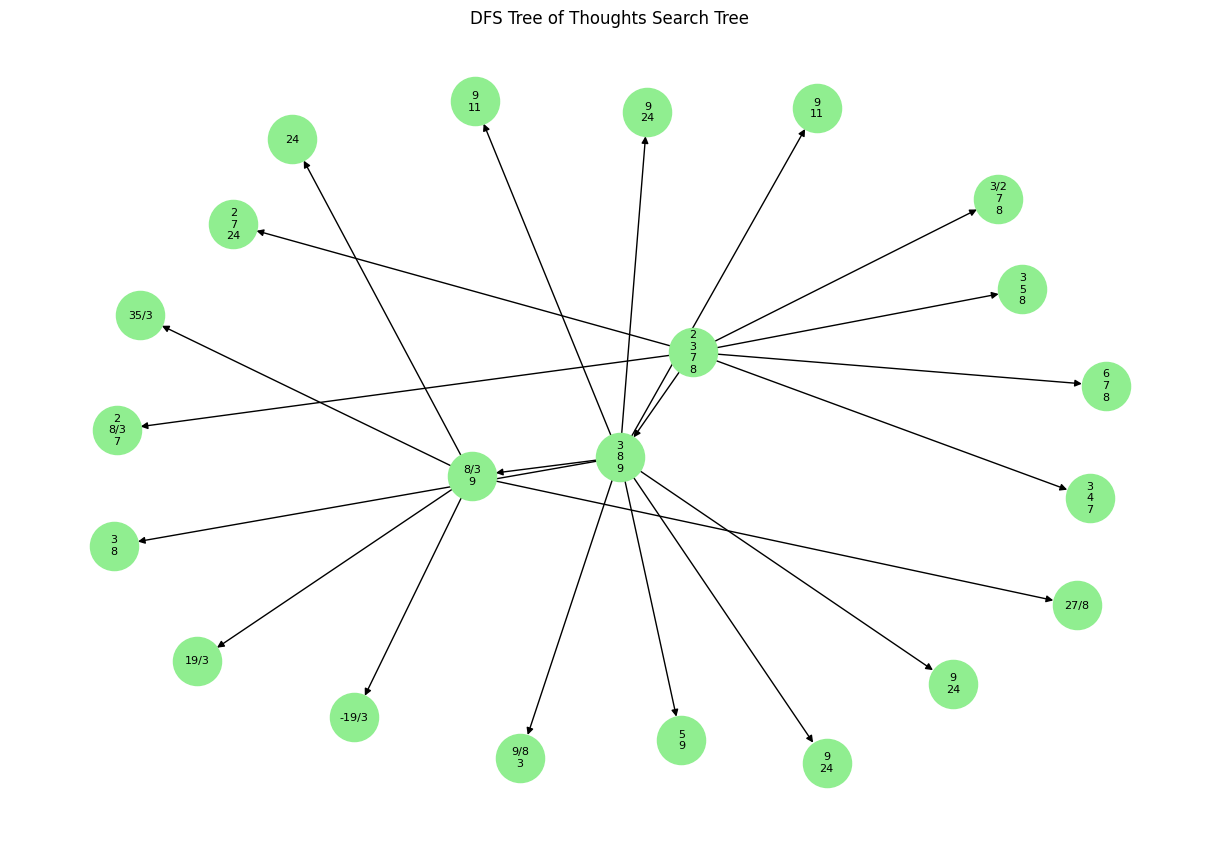

In [8]:
!pip -q install groq networkx matplotlib

import re
import networkx as nx
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
from fractions import Fraction

# -------------------------
# Load Groq API key
# -------------------------
try:
    from google.colab import userdata
    GROQ_KEY = userdata.get("GROQ_API_KEY")
except:
    GROQ_KEY = None

if not GROQ_KEY:
    raise ValueError("Add GROQ_API_KEY to Colab Secrets")

from groq import Groq
client = Groq(api_key=GROQ_KEY)

# -------------------------
# CONFIG
# -------------------------
TEMPERATURE = 0.7
T = 3
K = 8
VALUE_SAMPLES = 3
VALUE_THRESHOLD = 0.5

MODEL_CANDIDATES = [
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "mixtral-8x7b-32768",
    "gemma2-9b-it",
]

OPS = ["+","-","*","/"]

# -------------------------
# Tree Tracking
# -------------------------
SEARCH_TREE = nx.DiGraph()
NODE_COUNTER = 0
EXPLORED = 0

# -------------------------
# Helpers
# -------------------------
def frac_to_str(x):
    return str(x.numerator) if x.denominator==1 else f"{x.numerator}/{x.denominator}"

def normalize(nums):
    return sorted(nums,key=lambda z:(float(z),z.numerator,z.denominator))

def str_to_frac(s):
    if "/" in s:
        a,b=s.split("/")
        return Fraction(int(a),int(b))
    return Fraction(int(s),1)

def apply_op(a,b,op):
    if op=="+": return a+b
    if op=="-": return a-b
    if op=="*": return a*b
    if op=="/":
        if b==0: return None
        return a/b

def is_goal(nums):
    return len(nums)==1 and nums[0]==24

# -------------------------
# State
# -------------------------
@dataclass
class State:
    nums: List[Fraction]
    steps: List[str]=field(default_factory=list)
    node_id:int=-1
    parent_id:int=-1

# -------------------------
# Register node
# -------------------------
def register_node(state,depth):

    global NODE_COUNTER,EXPLORED

    NODE_COUNTER+=1
    EXPLORED+=1

    state.node_id=NODE_COUNTER

    SEARCH_TREE.add_node(
        state.node_id,
        nums=[frac_to_str(x) for x in normalize(state.nums)],
        depth=depth
    )

    if state.parent_id!=-1:
        SEARCH_TREE.add_edge(state.parent_id,state.node_id)

# -------------------------
# Groq chat with fallback
# -------------------------
def groq_chat(prompt):

    for model in MODEL_CANDIDATES:
        try:
            r=client.chat.completions.create(
                model=model,
                messages=[{"role":"user","content":prompt}],
                temperature=TEMPERATURE
            )
            return r.choices[0].message.content.strip()
        except:
            continue

    raise RuntimeError("All models failed")

# -------------------------
# Prompts
# -------------------------
# ---------------------------
# Few-shot examples (SOLVED)
# ---------------------------
# These examples are ONLY for teaching the formatting and the "left:" correctness.
PROPOSE_EXAMPLE = """
Examples:
1. Remaining numbers: 4 9 10 13
Possible next steps:
13 - 9 = 4 (left: 4 4 10)
10 - 4 = 6 (left: 4 6)
4 * 6 = 24 (left: 24)
2. Remaining numbers: 3 3 8 8
Possible next steps:
8 / 3 = 8/3 (left: 8/3 3 8)
3 - 8/3 = 1/3 (left: 1/3 8)
8 / 1/3 = 24 (left: 24)
3. Remaining numbers: 1 2 3 4
Possible next steps:
1 * 2 = 2 (left: 2 3 4)
2 * 3 = 6 (left: 6 4)
4 * 6 = 24 (left: 24)
4. Remaining numbers: 5 5 5 1
Possible next steps:
1 / 5 = 1/5 (left: 1/5 5 5)
5 - 1/5 = 24/5 (left: 24/5 5)
24/5 * 5 = 24 (left: 24)
5. Remaining numbers: 4 4 10 13
Possible next steps:
4 / 4 = 1 (left: 1 10 13)
10 + 13 = 23 (left: 23 1)
23 + 1 = 24 (left: 24)
6. Remaining numbers: 2 7 8 3
Possible next steps:
8 / 3 = 8/3 (left: 8/3 2 7)
2 + 7 = 9 (left: 9 8/3)
9 * 8/3 = 24 (left: 24)
""".strip()

VALUE_EXAMPLE = """
Example evaluations:
Remaining numbers: 4 6
sure

Remaining numbers: 3 8
sure

Remaining numbers: 9 8 3
sure

Remaining numbers: 9 8/3
sure

Remaining numbers: 1 1 1
impossible

Remaining numbers: 3 8 8
maybe
""".strip()

# ---------------------------
# Prompts (with examples)
# ---------------------------
def propose_prompt(nums: List[Fraction], k: int) -> str:
    nums_str = " ".join(frac_to_str(x) for x in nums)
    return f"""
You are playing the Game of 24.
Goal: use +, -, *, / to reach 24.

{PROPOSE_EXAMPLE}

Now propose {k} DIFFERENT valid next steps.

Remaining numbers: {nums_str}

Each next step MUST:
- pick exactly two numbers from the remaining numbers
- apply one operation (+,-,*,/)
- produce the result
- show the remaining numbers after the step

Return EXACTLY {k} lines, each in this format:
a op b = c (left: n1 n2 n3 ...)

Rules:
- "left:" must be the exact remaining multiset after using a and b and adding c
- Use integers or fractions like 3/2
- No extra text, no numbering, no explanations
""".strip()

def value_prompt(nums: List[Fraction]) -> str:
    nums_str = " ".join(frac_to_str(x) for x in nums)
    return f"""
You are evaluating a partial Game of 24 state.

{VALUE_EXAMPLE}

Now evaluate this state:
Remaining numbers: {nums_str}

Classify reachability of 24:
- sure
- maybe
- impossible

Output ONLY ONE WORD: sure, maybe, or impossible.
""".strip()

# -------------------------
# Step parsing
# -------------------------
# STEP_RE=re.compile(
# r"^\s*([-\d/]+)\s*([\+\-\*/])\s*([-\d/]+)\s*=\s*([-\d/]+)\s*\(left:\s*([-\d/\s]+)\)\s*$"
# )
STEP_RE = re.compile(r"([-\d/]+)\s*([\+\-\*/])\s*([-\d/]+)")

from collections import Counter

def validate_step(nums, line):

    m = STEP_RE.search(line)
    if not m:
        return None

    a_str, op_symbol, b_str = m.groups()

    try:
        a = str_to_frac(a_str)
        b = str_to_frac(b_str)
    except:
        return None

    counts = Counter(nums)

    if counts[a] == 0:
        return None
    counts[a] -= 1

    if counts[b] == 0:
        return None

    tmp = nums.copy()
    tmp.remove(a)
    tmp.remove(b)

    out = apply_op(a, b, op_symbol)
    if out is None:
        return None

    tmp.append(out)

    step = f"{frac_to_str(a)} {op_symbol} {frac_to_str(b)} = {frac_to_str(out)}"

    return step, tmp

# -------------------------
# Scoring
# -------------------------
def label_score(l):

    l=l.lower()

    if "sure" in l: return 2
    if "maybe" in l: return 1
    if "impossible" in l: return 0

    return 1

def evaluate(nums):

    total=0
    labels=[]

    for _ in range(VALUE_SAMPLES):

        r=groq_chat(value_prompt(nums))
        labels.append(r)
        total+=label_score(r)

    return total/VALUE_SAMPLES,labels

def enumerate_moves(nums):

    moves = []

    for i in range(len(nums)):
        for j in range(len(nums)):

            if i == j:
                continue

            a = nums[i]
            b = nums[j]

            rest = [nums[k] for k in range(len(nums)) if k not in (i, j)]

            for op in OPS:

                out = apply_op(a, b, op)

                if out is None:
                    continue

                new_nums = rest + [out]

                step = f"{frac_to_str(a)} {op} {frac_to_str(b)} = {frac_to_str(out)}"

                moves.append((step, new_nums))

    return moves

# -------------------------
# DFS Search
# -------------------------
def dfs(state,depth):

    if is_goal(state.nums):
        return state

    if depth>T:
        return None

    print(f"\nDFS depth {depth}")
    print("State:",[frac_to_str(x) for x in state.nums])

    raw=groq_chat(propose_prompt(state.nums,K))
    lines=[l.strip() for l in raw.split("\n") if l.strip()]

    scored_children = []

    for l in lines:

        v = validate_step(state.nums, l)

        if v:
            step, new_nums = v
            child = State(new_nums, state.steps + [step])
            child.parent_id = state.node_id

            register_node(child, depth)

            score, labels = evaluate(new_nums)

            print("Candidate:", step, "score", score)

            if score > VALUE_THRESHOLD:
                scored_children.append((score, child))

    # fallback if LLM failed
    if not scored_children:

        print("LLM produced no valid steps — using deterministic enumeration")

        for step, new_nums in enumerate_moves(state.nums):

            child = State(new_nums, state.steps + [step])
            child.parent_id = state.node_id

            register_node(child, depth)

            score, _ = evaluate(new_nums)

            scored_children.append((score, child))

    # sort by score
    scored_children.sort(key=lambda x: x[0], reverse=True)
    children = [c for _, c in scored_children]

    for c in children:

        r=dfs(c,depth+1)

        if r:
            return r

    return None

# -------------------------
# Plot tree
# -------------------------
def plot_tree():

    plt.figure(figsize=(12,8))

    pos=nx.spring_layout(SEARCH_TREE)

    labels={}
    for n in SEARCH_TREE.nodes():
        nums=SEARCH_TREE.nodes[n]["nums"]
        labels[n]="\n".join(nums)

    nx.draw(
        SEARCH_TREE,
        pos,
        labels=labels,
        with_labels=True,
        node_color="lightgreen",
        node_size=1200,
        font_size=8
    )

    plt.title("DFS Tree of Thoughts Search Tree")
    plt.show()

# -------------------------
# Run
# -------------------------
# ---------------------------
# Examples + Custom entry
# ---------------------------
EXAMPLES = {
    "1) Example": [4, 9, 10, 13],
    "2) Example": [1, 3, 4, 6],
    "3) Example": [2, 7, 8, 3],     # (8 - 2) * (7 - 3) = 8/3 * (7 + 2)= 24
    "4) Example": [5, 5, 5, 1],
}

print("Available examples:")
for name, nums in EXAMPLES.items():
    print(f"  {name}: {nums}")

print("\nChoose one:")
print("  - Enter 1/2/3/4 for an example")
print("  - OR type 'custom' to enter your own 4 numbers")

choice = input("\nYour choice: ").strip().lower()

if choice == "custom":
    raw = input("Enter 4 numbers separated by spaces (e.g. 4 9 10 13): ").strip()
    parts = raw.split()
    if len(parts) != 4:
        raise ValueError("❌ Please enter exactly 4 numbers.")
    start = [int(x) for x in parts]
else:
    idx = int(choice)
    if idx not in [1,2,3,4]:
        raise ValueError("❌ Invalid choice.")
    start = list(EXAMPLES.values())[idx-1]

nums = start

root=State([Fraction(x) for x in nums])
register_node(root,0)

solution=dfs(root,1)

print("\n==============================")

if solution:
    print("Solution found:\n")
    for s in solution.steps:
        print(s)
else:
    print("No solution found")

print("\nNodes explored:",EXPLORED)

plot_tree()